In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [2]:
print("numpy ", np.__version__)
print("pandas",pd.__version__)
print("Seaborn",sns.__version__)
print("Matplotlib :",matplotlib.__version__)

numpy  2.0.2
pandas 2.2.2
Seaborn 0.13.2
Matplotlib : 3.10.0


In [3]:
df = pd.read_csv('/content/Social Media Engagement Dataset.csv')

In [4]:
df

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7310,gn9gnl4zw1n7,2024-09-14 05:22:44,Saturday,Reddit,user_lo0o4vmh,"Rio de Janeiro, Brazil",hi,Comparing Toyota Sienna to the competition. Di...,#Sustainable,"@RetailSupport, @ReviewSite",...,500,25022,0.03872,Toyota,Sienna,ValentinesDeals,Pre-Launch,-0.9369,-0.0154,69.6
7311,gv0kvgyuvb97,2024-07-08 21:09:53,Monday,YouTube,user_hp7siejv,"Dubai, UAE",ar,My one month review of Pepsi Crystal Pepsi: Do...,"#ProductLaunch, #Eco",NaN,...,29,56166,0.05985,Pepsi,Crystal Pepsi,BlackFriday,Post-Launch,0.1598,-0.0574,89.4
7312,nk4w5cojxan6,2024-08-11 23:29:30,Sunday,Facebook,user_mzdo1snl,"Dubai, UAE",ja,Has anyone else experienced battery problems w...,"#MustHave, #Deal, #Travel",NaN,...,814,66892,0.01795,Apple,Mac Mini,SpringBlast2025,Pre-Launch,-0.9686,0.0989,-61.7
7313,l8tq067mvsr6,2025-03-28 03:55:54,Friday,Reddit,user_gvvmqc31,"Milan, Italy",ru,Any advice about Google's Pixel 8? #SpecialOf...,"#SpecialOffer, #TrendAlert, #Food",NaN,...,447,68012,0.07378,Google,Pixel 8,LaunchWave,Pre-Launch,0.5825,-0.4220,66.9


In [5]:
df.isnull().sum()

,0
post_id,0
timestamp,0
day_of_week,0
platform,0
user_id,0
location,0
language,0
text_content,0
hashtags,0
mentions,2419


In [6]:
df.drop('mentions', axis= 1,  inplace = True)

In [7]:
df.isnull().sum()

,0
post_id,0
timestamp,0
day_of_week,0
platform,0
user_id,0
location,0
language,0
text_content,0
hashtags,0
keywords,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7315 entries, 0 to 7314
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_id                  7315 non-null   object 
 1   timestamp                7315 non-null   object 
 2   day_of_week              7315 non-null   object 
 3   platform                 7315 non-null   object 
 4   user_id                  7315 non-null   object 
 5   location                 7315 non-null   object 
 6   language                 7315 non-null   object 
 7   text_content             7315 non-null   object 
 8   hashtags                 7315 non-null   object 
 9   keywords                 7315 non-null   object 
 10  topic_category           7315 non-null   object 
 11  sentiment_score          7315 non-null   float64
 12  sentiment_label          7315 non-null   object 
 13  emotion_type             7315 non-null   object 
 14  toxicity_score          

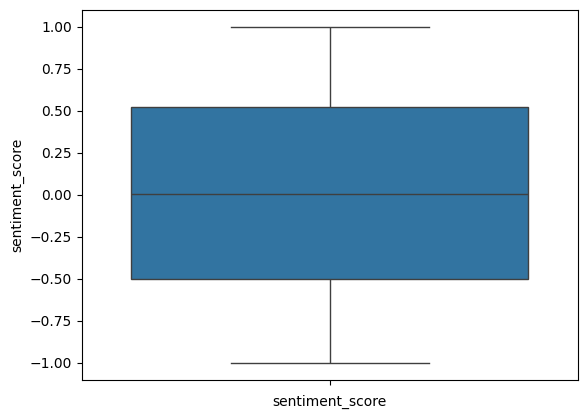

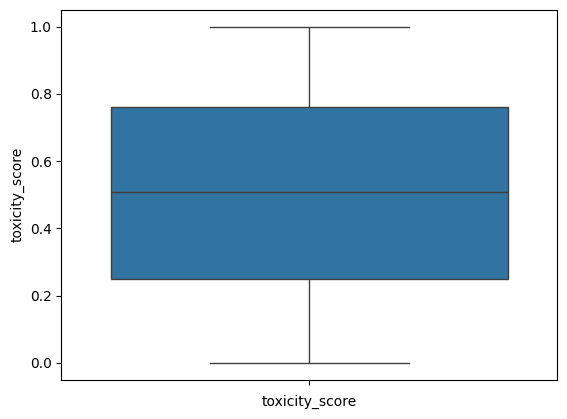

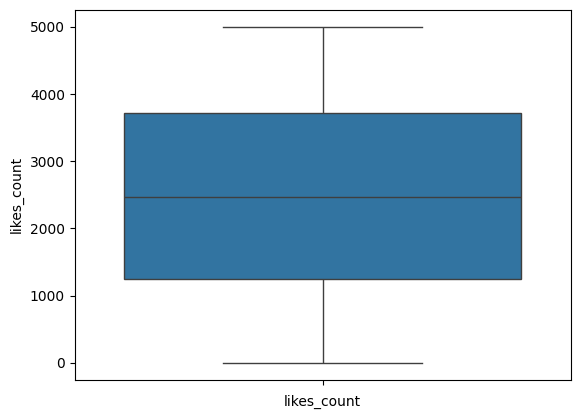

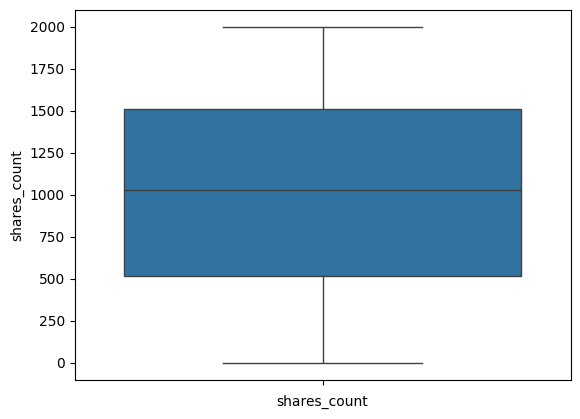

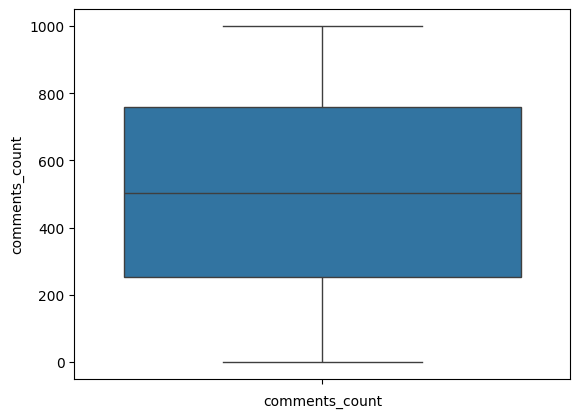

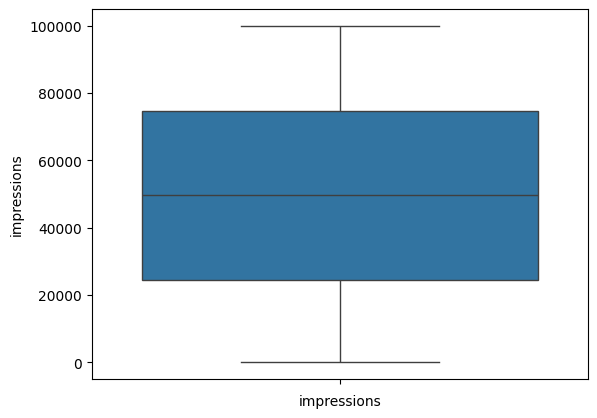

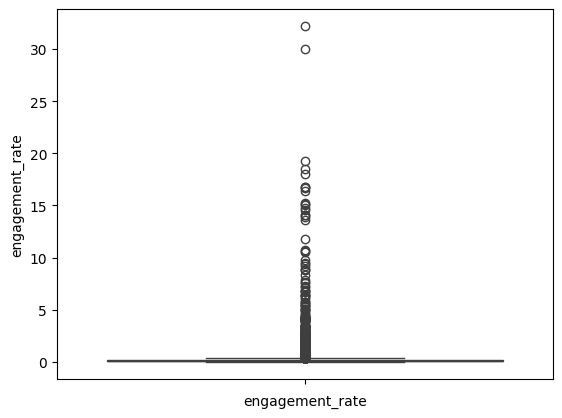

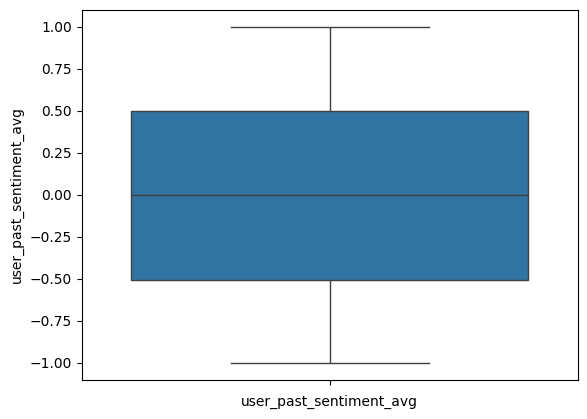

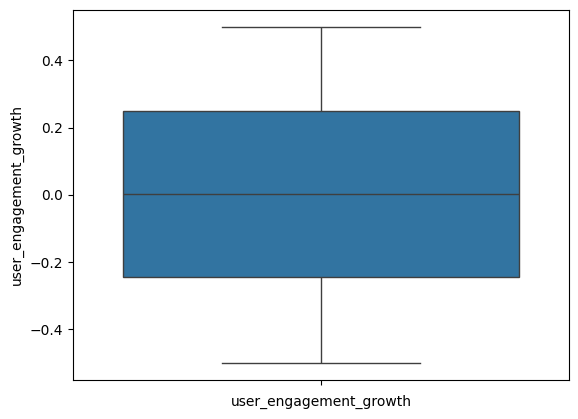

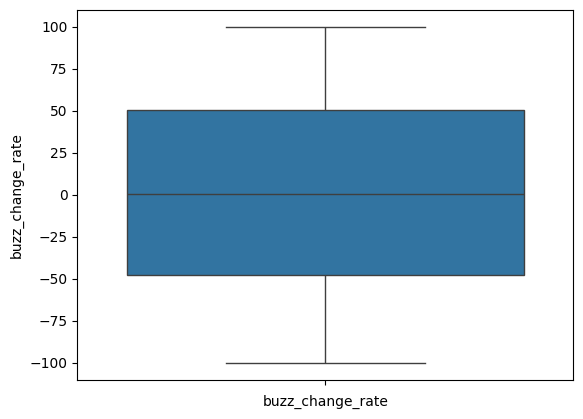

In [10]:
for i in df.columns:
  if(df[i].dtype!='object'):
    sns.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
encoders = {}
for i in df.columns:
  if df[i].dtype =='object':
    le=LabelEncoder()
    df[i] = le.fit_transform(df[i])
    encoders[i]=le

In [13]:
encoders = {}
for i in df.columns:
  if df[i].dtype =='datetime64[ns]':
    le=LabelEncoder()
    df[i] = le.fit_transform(df[i])
    encoders[i]=le

In [14]:
df['engagement_rate'] = np.where(df['engagement_rate'] >= 0.1, 1, 0)

In [15]:
df['engagement_rate'] = df['engagement_rate'].map({1: 'Yes', 0: 'No'})

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [17]:
x = df.drop(columns=['engagement_rate'],axis=1)
y = df['engagement_rate']

In [18]:
x

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,keywords,...,shares_count,comments_count,impressions,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,4035,4449,1,1,1014,15,7,4144,1083,3920,...,1704,701,18991,4,6,1,0,0.0953,-0.3672,19.1
1,6363,1751,3,3,6179,30,8,3740,1647,873,...,1803,359,52764,5,57,15,1,0.1369,-0.4510,-42.6
2,4450,4114,2,2,1564,1,8,7256,2065,4270,...,705,643,8887,6,17,1,1,0.2855,-0.4112,17.4
3,2310,2722,1,4,931,9,2,1215,2343,2618,...,262,743,6696,7,13,10,0,-0.2094,-0.0167,-5.5
4,2490,2509,4,3,4252,2,5,4190,1283,2751,...,1443,703,47315,9,10,11,0,0.6867,0.0807,38.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7310,3341,2680,2,2,4371,23,5,2106,2581,4927,...,42,500,25022,9,51,21,2,-0.9369,-0.0154,69.6
7311,3384,1367,1,4,3588,6,0,5796,1943,2548,...,1608,29,56166,7,11,1,1,0.1598,-0.0574,89.4
7312,4677,2013,3,0,4639,6,6,2503,1626,4534,...,360,814,66892,2,31,17,2,-0.9686,0.0989,-61.7
7313,4211,6607,0,2,3428,17,8,241,2571,3002,...,1580,447,68012,4,41,10,2,0.5825,-0.4220,66.9


In [19]:
y

,engagement_rate
0,Yes
1,No
2,Yes
3,Yes
4,No
...,...
7310,No
7311,No
7312,No
7313,No


In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=0)

In [21]:
model = DecisionTreeClassifier()

In [22]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [23]:
y_predict = model.predict(x_test)

In [24]:
y_predict

array(['Yes', 'No', 'Yes', ..., 'No', 'No', 'No'], dtype=object)

In [25]:
accuracy_score(y_predict,y_test)*100

95.01025290498974

In [26]:
pip install scikit-learn pandas joblib

In [28]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']